In [146]:
import numpy as np
import math as m

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

import matplotlib.pyplot as plt

# Two ways to read out a circuit:
#   qasm_sim  -> samples bitstrings (counts). Used by the "measure" method.
#   exact "method" doesn't need a simulator at all: Statevector(qc) gives the
#   amplitudes directly. We'll use that in the cost function for the noise-free path.
qasm_sim = AerSimulator()

## The problem

We want the **ground-state energy** of the single-qubit Hamiltonian

$$H = 3X - 2Y + 1Z$$

stored as a Pauli dictionary `H = {'X': 3, 'Y': -2, 'Z': 1}`.

The ground-state energy is the smallest eigenvalue of `H`. For a single-qubit
sum `aX + bY + cZ` the eigenvalues are exactly `±√(a² + b² + c²)`, so the exact
answer we're aiming for is

$$E_0 = -\sqrt{3^2 + (-2)^2 + 1^2} = -\sqrt{14} \approx -3.742$$

**Plan:** prepare a tunable state `|ψ(θ, φ)⟩` (the ansatz), measure its energy
`⟨H⟩(θ, φ)`, and use gradient descent to drive that energy down toward `E_0`.

In [147]:
def single_qubit_ansatz(qc, qbit_index, params):
    # params 0 is Ry, theta  and params 1 is Rz phi azimuthal
    qc.ry(params[0], qbit_index)
    qc.rz(params[1], qbit_index)
# general state form cos(θ/2)|0⟩ + e^(iφ) sin(θ/2)|1⟩

# test the method
qc = QuantumCircuit(1)
single_qubit_ansatz(qc, 0, [0, 0])
Statevector(qc)


Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [148]:
def expectation_value(params, ansatz, H, method, shots=10000):

    total = 0.0
    for pauli_str, coeff in H.items():

        if method =="exact":
            qc = QuantumCircuit(1)
            ansatz(qc, 0, params)
            psi = Statevector(qc)
            qc2 = qc.copy()
            # here we are appplying components of H 1 by 1
            if pauli_str == "X":
                qc2.x(0)
            elif pauli_str == "Y":
                qc2.y(0)
            elif pauli_str == "Z":
                qc2.z(0)
            psi2 = Statevector(qc2)

            term = np.vdot(psi.data, psi2.data).real

        elif method == "measure":
            qc = QuantumCircuit(1, 1)
            ansatz(qc, 0, params)
            if pauli_str == "X":
                qc.ry(-m.pi/2, 0)
            elif pauli_str == "Y":
                qc.rx(m.pi/2, 0)
            # Z needs no rotation
            qc.measure(0,0)
            counts = qasm_sim.run(qc, shots=shots).result().get_counts()
            # parity rule: <Pauli> = (1/shots) * sum (-1)^(#ones) * count
            term = 0
            for bitstr, n in counts.items():
                parity = (-1) ** bitstr.count("1")
                term+= parity * n
            term /= shots

        total += coeff * term # ⟨H⟩ = 3·⟨X⟩  − 2·⟨Y⟩  + 1·⟨Z⟩

    return total

# test expectation value
H = {'X': 3, 'Y':-2, 'Z': 1}
params = [1.0, 2.0]
print("exact:", expectation_value(params, single_qubit_ansatz, H, "exact"))
print("measured:", expectation_value(params, single_qubit_ansatz, H, "measure"))

exact: -2.0405189617224893
measured: -2.0216000000000003


In [149]:
def gradient_descent(init_params, cost_fn, step, eps, max_iters):
    conv_threshold = 1e-6
    params = np.array(init_params, dtype=float)
    energy = cost_fn(params)
    trajectory = [energy] # store the trajectory
    def finite_diff_grad(p):
        grad = np.zeros(len(p))
        for i in range(len(p)):
            p_plus = p.copy()
            p_plus[i] +=eps
            p_minus = p.copy()
            p_minus[i] -=eps
            grad[i] = (cost_fn(p_plus) - cost_fn(p_minus)) / (2*eps)
        return grad
    
    for _ in range(max_iters):
        grad = finite_diff_grad(params)

        #1. Step downhill based on sign of gradient
        params = params - step*grad # element wise subtract

        #2. evaluate energy
        new_energy = cost_fn(params)

        #3. record the energy
        trajectory.append(new_energy)

        #4. check for convergence
        if abs(new_energy - energy) < conv_threshold:
            break

        energy = new_energy

    return params, energy, trajectory


In [150]:
f =lambda p: expectation_value(p, single_qubit_ansatz, H, "exact")

init_params = np.array([np.random.random()*np.pi, np.random.random() * 2 * np.pi])

final_params, final_energy, trajectory = gradient_descent(init_params, f, step=0.1, eps=1e-6, max_iters=100)

# calculated E for the H
E_calc = -np.sqrt(14)

print("Exact method:")
print("total iterations", len(trajectory)-1)
print("Start energy", round(trajectory[0], 5))
print("Final energy", round(final_energy, 5))
print("Calculated energy", round(E_calc, 5))
print("error", round(abs(final_energy - E_calc), 5))
print("Final params", final_params)


f_measure = lambda p: expectation_value(p, single_qubit_ansatz, H, "measure", shots=10000)

# reuse the SAME starting point as the exact run, so the only difference is the noise
final_params_m, final_energy_m, trajectory_m = gradient_descent(
    init_params, f_measure, step=0.1, eps=0.3, max_iters=100
)

print("Noisy Measure method:")
print("Start energy", round(trajectory_m[0], 5))
print("Final energy", round(final_energy_m, 5))
print("Exact E0    ", round(E_calc, 5))
print("error       ", round(abs(final_energy_m - E_calc), 5))
print("iterations  ", len(trajectory_m) - 1)
print("Final params", final_params_m)


Exact method:
total iterations 18
Start energy -2.02543
Final energy -3.74166
Calculated energy -3.74166
error 0.0
Final params [1.84130051 2.5531123 ]
Noisy Measure method:
Start energy -1.9846
Final energy -3.7608
Exact E0     -3.74166
error        0.01914
iterations   100
Final params [1.84117574 2.53423197]


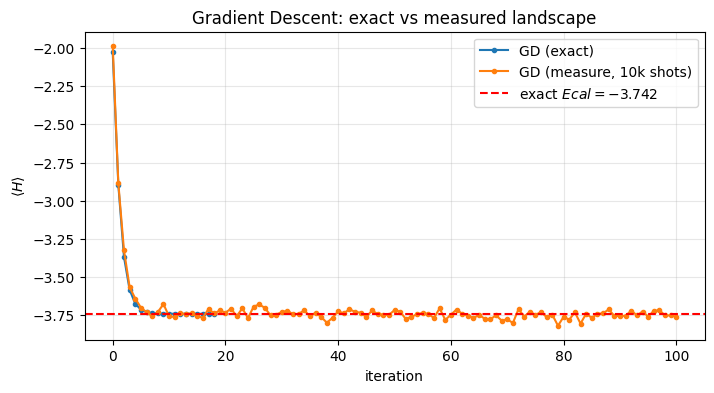

In [151]:
# plot exact vs measure on the same axes
plt.figure(figsize=(8, 4))
plt.plot(trajectory,   marker="o", markersize=3, label="GD (exact)")
plt.plot(trajectory_m, marker="o", markersize=3, label="GD (measure, 10k shots)")
plt.axhline(E_calc, color="red", linestyle="--", label=f"exact $Ecal = {E_calc:.3f}$")

plt.xlabel("iteration")
plt.ylabel(r"$\langle H \rangle$")
plt.title("Gradient Descent: exact vs measured landscape")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [152]:
# Nelder mead 
def move_toward(start, target, factor):
    return start + factor * (target-start)

def nelder_mead(init_simplex, cost_fn, max_iters):
    vertices = [np.array(points, dtype=float) for points in init_simplex] # simplex means simple polygon which triangle.
    costs_vertices = [cost_fn(vertex) for vertex in vertices] # this is each vertex's energy the 3-D
    trajectory = [min(costs_vertices)]

    for _ in range(max_iters):
        best_vertex_index = np.argmin(costs_vertices)
        worst_vertex_index = np.argmax(costs_vertices)
        second_worst_index = np.argsort(costs_vertices)[-2]

        # find the centroid which is avergae of the 2 non worst vertices
        centroid = np.mean([vertex for i, vertex in enumerate(vertices) if i!=worst_vertex_index], axis=0)

        # 1 lets reflect the worst vertex across
        alpha = 1.0
        reflected_point = move_toward(centroid, vertices[worst_vertex_index], -alpha)
        # mirrored point = centroid + dist between centroid and worst point
        reflected_cost = cost_fn(reflected_point)

        # now evaluate the reflected point
        gamma = 2.0
        best_cost = costs_vertices[best_vertex_index]

        # mirroring
        if reflected_cost < best_cost: # note: cost lower means better
            expanded_point = move_toward(centroid, reflected_point, gamma)
            expanded_cost = cost_fn(expanded_point)
            if expanded_cost < reflected_cost: # expanded is better than reflected
                vertices[worst_vertex_index] = expanded_point
                costs_vertices[worst_vertex_index] = expanded_cost
            else:
                vertices[worst_vertex_index] = reflected_point
                costs_vertices[worst_vertex_index] = reflected_cost
        elif reflected_cost < costs_vertices[second_worst_index]: # worse than best but better than the worst
            vertices[worst_vertex_index] = reflected_point
            costs_vertices[worst_vertex_index] = reflected_cost
        else:
            rho = 0.5
            contracted_point = move_toward(centroid, reflected_point, rho) # we went till reflected point found it bad so we are no retracting abck towards centroid
            contracted_cost = cost_fn(contracted_point)
            if contracted_cost < costs_vertices[worst_vertex_index]:
                vertices[worst_vertex_index] = contracted_point
                costs_vertices[worst_vertex_index] = contracted_cost
            else:
                sigma = 0.5
                best_point = vertices[best_vertex_index]
                for i in range(len(vertices)):
                    if i!=best_vertex_index:
                        vertices[i] = move_toward(best_point, vertices[i], sigma)
                        costs_vertices[i] = cost_fn(vertices[i])
        trajectory.append(min(costs_vertices))                

    best_index = np.argmin(costs_vertices)
    return vertices[best_index], costs_vertices[best_index], trajectory


In [153]:
delta = 0.4
simplex = [init_params, 
           init_params + np.array([delta, 0.0]),
           init_params + np.array([0.0, delta]),
           ]

cost_fn = lambda p :expectation_value(p, single_qubit_ansatz, H, "exact")
nm_params, nm_energy, nm_trajectory = nelder_mead(simplex, cost_fn, max_iters=200)

print("Nelder-Mead (exact):")
print("Start energy ", round(nm_trajectory[0], 5))
print("Final energy ", round(nm_energy, 5))
print("Exact E0     ", round(E_calc, 5))
print("error        ", round(abs(nm_energy - E_calc), 5))
print("iterations   ", len(nm_trajectory) - 1)
print("Final params ", nm_params)


Nelder-Mead (exact):
Start energy  -3.01441
Final energy  -3.74166
Exact E0      -3.74166
error         0.0
iterations    200
Final params  [1.84134609 2.55359004]


Nelder-Mead (measure): final -3.8294  error 0.08774


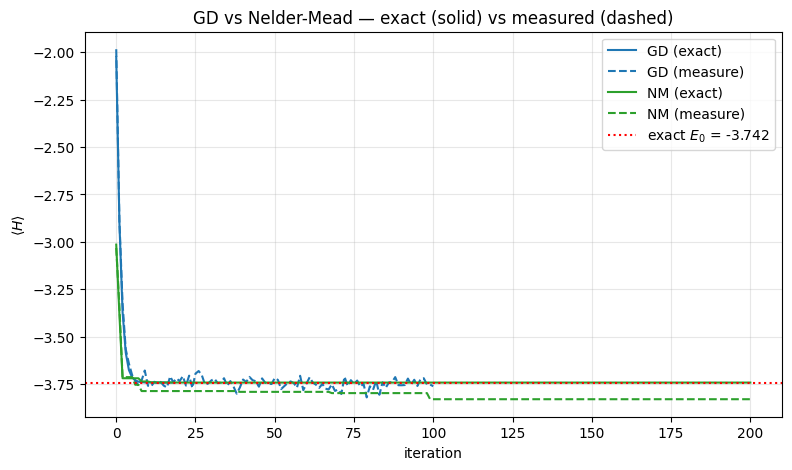

In [154]:
# Nelder-Mead on the NOISY landscape (same simplex, just measure)
cost_fn_measure = lambda p: expectation_value(p, single_qubit_ansatz, H, "measure", shots=10000)
nm_params_m, nm_energy_m, nm_trajectory_m = nelder_mead(simplex, cost_fn_measure, max_iters=200)

print("Nelder-Mead (measure): final", round(nm_energy_m, 5), " error", round(abs(nm_energy_m - E_calc), 5))

# compare all four: GD vs NM, exact vs measure
plt.figure(figsize=(9, 5))
plt.plot(trajectory,      label="GD (exact)",      color="tab:blue")
plt.plot(trajectory_m,    label="GD (measure)",    color="tab:blue",   linestyle="--")
plt.plot(nm_trajectory,   label="NM (exact)",      color="tab:green")
plt.plot(nm_trajectory_m, label="NM (measure)",    color="tab:green",  linestyle="--")
plt.axhline(E_calc, color="red", linestyle=":", label=f"exact $E_0$ = {E_calc:.3f}")

plt.xlabel("iteration")
plt.ylabel(r"$\langle H \rangle$")
plt.title("GD vs Nelder-Mead — exact (solid) vs measured (dashed)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
